# Graph Neural Network (GNN) - PyTorch




--- Starting Training ---
Epoch   0 | Loss: 0.6914 | Train Acc: 0.5833
Epoch  20 | Loss: 0.4546 | Train Acc: 0.9167
Epoch  40 | Loss: 0.2085 | Train Acc: 0.9583
Epoch  60 | Loss: 0.0991 | Train Acc: 0.9583
Epoch  80 | Loss: 0.0660 | Train Acc: 0.9583
Epoch 100 | Loss: 0.0456 | Train Acc: 1.0000
Epoch 120 | Loss: 0.0574 | Train Acc: 1.0000
Epoch 140 | Loss: 0.0242 | Train Acc: 1.0000
Epoch 160 | Loss: 0.0355 | Train Acc: 1.0000
Epoch 180 | Loss: 0.0218 | Train Acc: 1.0000
Epoch 200 | Loss: 0.0103 | Train Acc: 1.0000

--- Final Test Accuracy: 1.0000 ---
Embeddings shape extracted successfully: (34, 16)


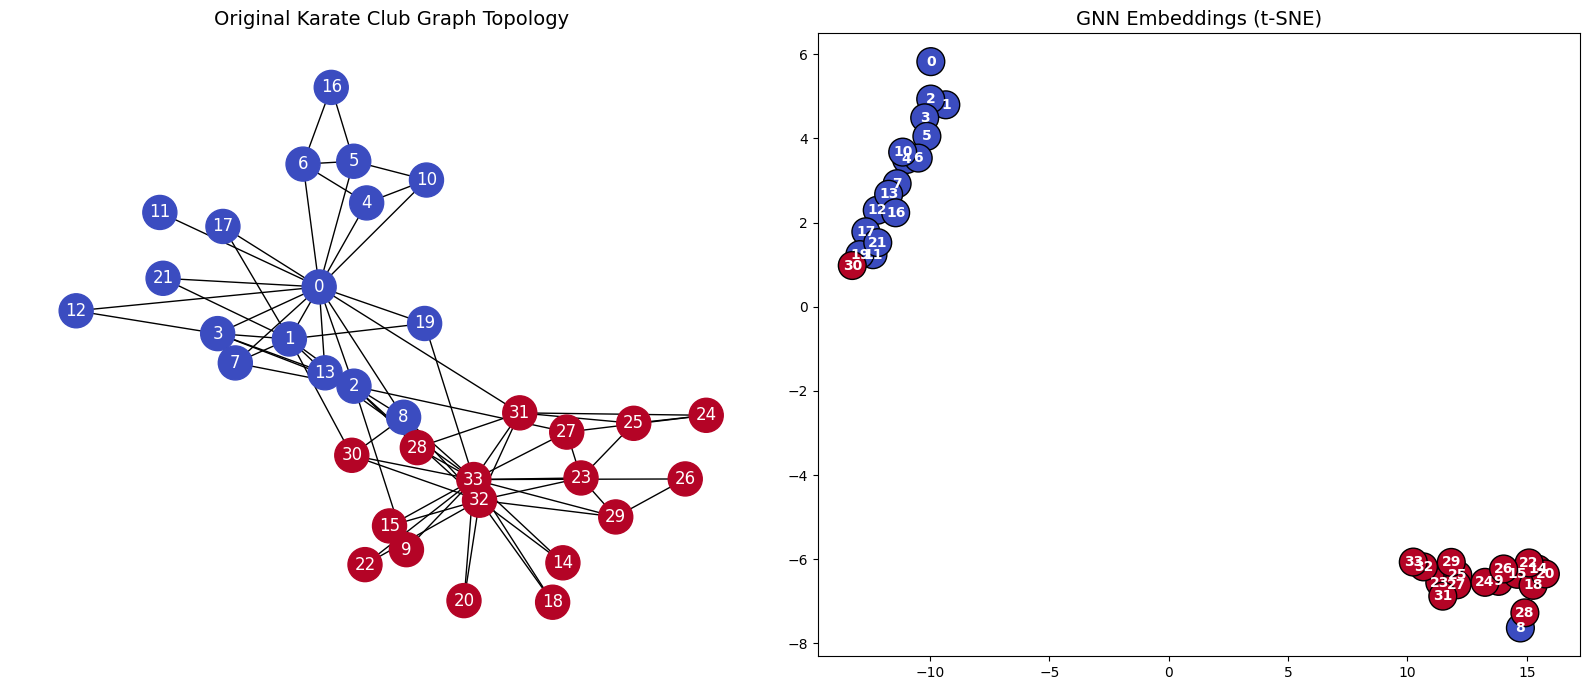

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ============================================================
# 1. CUSTOM GCN LAYER
# ============================================================

class GCNLayer(nn.Module):
    """Custom Graph Convolutional Layer in PyTorch."""
    def __init__(self, in_features, out_features):
        super(GCNLayer, self).__init__()
        # Define learnable weights
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        # Initialize weights using Glorot/Xavier uniform
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, A):
        # X: Node Features, A: Normalized Adjacency Matrix
        # X * W
        support = torch.mm(X, self.weight)
        # A * (X * W)
        output = torch.mm(A, support)
        return output

# ============================================================
# 2. MODEL ARCHITECTURE
# ============================================================

class KarateGCN(nn.Module):
    """2-Layer GCN Model."""
    def __init__(self, num_nodes, hidden_dim, num_classes):
        super(KarateGCN, self).__init__()
        self.gcn1 = GCNLayer(num_nodes, hidden_dim)
        self.dropout = nn.Dropout(0.5)
        self.gcn2 = GCNLayer(hidden_dim, num_classes)

    def forward(self, X, A):
        # First layer + ReLU
        emb = F.relu(self.gcn1(X, A))

        # Dropout
        h = self.dropout(emb)

        # Output layer (No Softmax here, handled by CrossEntropyLoss)
        out = self.gcn2(h, A)

        # We return both the logits and the embeddings for later visualization
        return out, emb

# ============================================================
# 3. DATA PREPARATION
# ============================================================

def prepare_karate_club_data():
    """Loads and pre-processes data, converting to PyTorch Tensors."""
    G = nx.karate_club_graph()
    N = G.number_of_nodes()

    # Features: Identity Matrix
    X = np.eye(N, dtype=np.float32)

    # Labels: 0 for 'Mr. Hi', 1 for 'Officer'
    labels = np.array([0 if G.nodes[i]['club'] == 'Mr. Hi' else 1 for i in G.nodes()])

    # Adjacency Matrix with Self-Loops
    A = nx.to_numpy_array(G, dtype=np.float32)
    A += np.eye(N)

    # Normalize Adjacency: D^(-1/2) * A * D^(-1/2)
    D = np.sum(A, axis=1)
    D_inv_sqrt = np.power(D, -0.5, where=D!=0)
    D_mat = np.diag(D_inv_sqrt)
    A_norm = (D_mat @ A @ D_mat).astype(np.float32)

    # Train/Test Split
    idx = np.arange(N)
    np.random.seed(42)
    np.random.shuffle(idx)

    train_idx, test_idx = idx[:24], idx[24:]

    train_mask = np.zeros(N, dtype=bool)
    train_mask[train_idx] = True

    test_mask = np.zeros(N, dtype=bool)
    test_mask[test_idx] = True

    # Convert everything to PyTorch Tensors
    X_tensor = torch.tensor(X)
    A_norm_tensor = torch.tensor(A_norm)
    labels_tensor = torch.tensor(labels, dtype=torch.long) # CrossEntropy expects long
    train_mask_tensor = torch.tensor(train_mask)
    test_mask_tensor = torch.tensor(test_mask)

    return G, X_tensor, A_norm_tensor, labels_tensor, train_mask_tensor, test_mask_tensor

# ============================================================
# 4. VISUALIZATION
# ============================================================

def visualize_results(G, embeddings, true_classes):
    """Visualizes original graph topology and t-SNE embeddings side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Original Graph Visualization
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        node_color=true_classes,
        cmap=plt.cm.coolwarm,
        node_size=600,
        with_labels=True,
        font_color="white",
        ax=axes[0])

    axes[0].set_title("Original Karate Club Graph Topology", fontsize=14)

    # Plot 2: t-SNE Visualization
    emb_2d = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(embeddings)

    axes[1].scatter(
        emb_2d[:, 0], emb_2d[:, 1],
        c=true_classes,
        cmap="coolwarm",
        s=400,
        edgecolors="black")

    for i in range(G.number_of_nodes()):
        axes[1].text(
            emb_2d[i, 0], emb_2d[i, 1], str(i),
            ha='center', va='center', color='white', fontweight='bold')

    axes[1].set_title("GNN Embeddings (t-SNE)", fontsize=14)

    plt.tight_layout()
    plt.show()

# ============================================================
# 5. MAIN EXECUTION (TRAIN & EVALUATE)
# ============================================================

def main():
    # 1. Load Data
    G, X, A_norm, labels, train_mask, test_mask = prepare_karate_club_data()
    N = G.number_of_nodes()

    # 2. Initialize Model, Loss, and Optimizer
    model = KarateGCN(num_nodes=N, hidden_dim=16, num_classes=2)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # PyTorch's CrossEntropyLoss combines LogSoftmax and NLLLoss in one single class
    criterion = nn.CrossEntropyLoss()

    # 3. Training Loop
    print("\n--- Starting Training ---")
    model.train() # Set model to training mode
    epochs = 200

    for epoch in range(epochs + 1):
        # Zero out previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits, _ = model(X, A_norm)

        # Calculate loss ONLY on training nodes
        loss = criterion(logits[train_mask], labels[train_mask])

        # Backward pass (calculate gradients)
        loss.backward()

        # Update weights
        optimizer.step()

        if epoch % 20 == 0:
            # Calculate accuracy
            preds = torch.argmax(logits, dim=1)
            correct = (preds[train_mask] == labels[train_mask]).sum().item()
            acc = correct / train_mask.sum().item()
            print(f"Epoch {epoch:>3} | Loss: {loss.item():.4f} | Train Acc: {acc:.4f}")

    # 4. Evaluation
    model.eval() # Set model to evaluation mode (disables dropout)
    with torch.no_grad(): # Disable gradient calculation for inference
        logits, embeddings = model(X, A_norm)
        preds = torch.argmax(logits, dim=1)

        correct_test = (preds[test_mask] == labels[test_mask]).sum().item()
        test_acc = correct_test / test_mask.sum().item()
        print(f"\n--- Final Test Accuracy: {test_acc:.4f} ---")

    # 5. Visualize (Convert tensors back to numpy for matplotlib/sklearn)
    numpy_embeddings = embeddings.numpy()
    numpy_labels = labels.numpy()

    print(f"Embeddings shape extracted successfully: {numpy_embeddings.shape}")
    visualize_results(G, numpy_embeddings, numpy_labels)

if __name__ == "__main__":
    main()